In [1]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks

In [2]:
def display_image_grayscale(image, title="Image"):
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_image_color(image, title="Image"):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()


In [3]:
def create_gaussian_kernel(L, sigma):
    '''This function creates a gaussian kernel used for smoothing'''
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None
    midpoint = L // 2
    kernel = [[0 for _ in range(L)] for _ in range(L)]
    total = 0
    for i in range(L):
        for j in range(L):
            y = (i - midpoint)
            x = (j - midpoint)
            value = (1/(2*math.pi*sigma**2)) * math.exp(-(x**2 + y**2)/(2*sigma**2))
            kernel[i][j] = value
            total += value
    for i in range(L):
        for j in range(L):
            kernel[i][j] /= total # Normalization
    return np.array(kernel)

In [4]:
@njit
def _apply_kernel(padded_image, kernel, padding_size):
    '''This function performs kernel operations for linear image filters. 
    It is a helper function for the convolution function
    It uses numba to optimize the function into optimized machine code
    '''
    N, M = padded_image.shape
    filtered_image = np.zeros_like(padded_image)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            image_window = padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            newPixel = np.sum(image_window * kernel)
            filtered_image[i, j] = newPixel
    return filtered_image


def linear_filter(image, kernel, clip=True):
    '''This function is a general image filter that works for various kernels
    Set clip=False for mathematical derivatives (Harris/Sobel).'''
    def convolution(image, kernel):
        L = len(kernel)
        padding_size = (L - 1) // 2
        padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
        filtered_image = _apply_kernel(padded_image, kernel, padding_size)
        filtered_image = filtered_image[padding_size: -padding_size, padding_size: -padding_size]
        if clip:
            return np.clip(filtered_image, 0, 255).astype(np.uint8)
        else:
            return filtered_image # Returns raw float32 values
    
    if len(kernel) % 2 == 0 or len(kernel) <= 0:
        print("Kernel size must be an odd integer")
        return None

    if len(image.shape) == 3: # RGB/BGR images
        channels = [convolution(image[:, :, i], kernel) for i in range(3)]
        return np.dstack(channels)
    else: # Grayscale images
        return convolution(image, kernel)

In [5]:
@njit
def _apply_median_kernel(padded_image, L, padding_size):
    '''This function performs kernel operations for median image filters.
    It uses numba to optimize the function into optimized machine code
    '''
    N, M = padded_image.shape
    im_filtered = np.zeros_like(padded_image)
    for i in range(padding_size, N-padding_size):
        for j in range(padding_size, M-padding_size):
            median = np.median(padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1])
            im_filtered[i, j] = median
    return im_filtered


def median_filter(image, L):
    '''Non-linear filter used for calculating the median value in a kernel. Useful for removing salt and pepper noise'''
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None
    if len(image.shape) == 2: # only grayscale images
        padding_size = (L-1) // 2
        padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
        filtered_image = _apply_median_kernel(padded_image, L, padding_size)
        return np.clip(filtered_image[padding_size: -padding_size, padding_size: -padding_size], 0, 255).astype(np.uint8)
    

In [6]:
def create_histogram(image, bin_size):
    '''Creates a (denormalized) histogram of an image. 
    The bin_size is the number of intensity levels and the histogram contains occurrences of each intensity level.
    '''
    np.bincount(image.ravel(), minlength=bin_size)
    hist = [0 for i in range(bin_size)]
    bin = [i for i in range(bin_size)]
    for i in range(len(image)):
        for j in range(len(image[i])):
            hist[image[i][j]] += 1
    return hist, bin

def create_normalized_histogram(image, bin_size):
    '''Creates a normalized histogram of an image. 
    The bin_size is the number of intensity levels and the histogram contains normalized occurrences of each intensity level.
    '''
    N,M = image.shape
    hist_norm = [0 for i in range(bin_size)]
    bin = [i for i in range(bin_size)]
    for i in range(len(image)):
        for j in range(len(image[i])):
            hist_norm[image[i][j]] += (1 / (N*M))
    return hist_norm, bin

In [7]:
def find_otsu_threshold(hist_norm):
    '''Finds the most optimal global threshold of an image using Otsu's algorithm
    Returns the optimal threshold value.'''
    def calculate_between_class_variance(hist_norm, T):
        # Todo: This function needs to be optimized in terms of time complexity
        P1, sum1 = 0, 0
        P2, sum2 = 0, 0
        for i in range(len(hist_norm)):
            if i < T:
                sum1 += (i * hist_norm[i])
                P1 += hist_norm[i]
            else:
                sum2 += (i * hist_norm[i])
                P2 += hist_norm[i]
        if P1 == 0 or P2 == 0:
            return 0
        m1 = sum1 / P1
        m2 = sum2 / P2
        variance = (P1*P2) * (m1-m2)**2
        return variance
    
    max_variance = 0
    best_threshold = 0
    for i in range(len(hist_norm)):
        variance = calculate_between_class_variance(hist_norm, i) # Todo: This line needs to be optimized
        if variance > max_variance:
            max_variance = variance
            best_threshold = i
    return best_threshold

def perform_threshold(image, threshold):
    '''Applies global thresholding to an image and returns the image'''
    N, M = image.shape
    image_threshold = np.zeros((N, M))
    for i in range(len(image_threshold)):
        for j in range(len(image_threshold[i])):
            if image[i][j] > threshold:
                image_threshold[i][j] = 255
            else:
                image_threshold[i][j] = 0
    return image_threshold

In [8]:
@njit
def _apply_threshold_kernel(padded_image, kernel, padding_size, C, inverse):
    '''This function performs kernel operations for adaptive thresholding.
    It is a helper function for the convolution function
    It uses numba to optimize the function into optimized machine code
    '''
    N, M = padded_image.shape
    threshold_image = np.zeros((N, M), dtype=np.uint8)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            image_window = padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            threshold = np.sum(image_window * kernel) - C
            if inverse == False:
                if padded_image[i,j] >= threshold:
                    threshold_image[i,j] = 255
                else:
                    threshold_image[i,j] = 0
            else:
                if padded_image[i,j] < threshold:
                    threshold_image[i,j] = 255 # Make ink white (for findContours)
                else:
                    threshold_image[i,j] = 0   # Make paper black
    return threshold_image
    
def apply_adaptive_threshold(image, L, C=0, inverse=False):
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None

    if len(image.shape) != 2: # Grayscale images
        print("Image must be grayscale to apply thresholding")
        return None
    kernel = create_gaussian_kernel(L, L/6)
    padding_size = (L - 1) // 2
    padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
    threshold_image = _apply_threshold_kernel(padded_image, kernel, padding_size, C, inverse)
    threshold_image = threshold_image[padding_size: -padding_size, padding_size: -padding_size]
    return threshold_image

In [9]:
@njit
def _compute_harris_response(I_x, I_y, window, window_size, padding_size, k, H, W):
    response = np.zeros((H, W))
    for i in range(padding_size, H-padding_size):
        for j in range(padding_size, W-padding_size):
            I_x_squared = np.square(I_x[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            I_y_squared = np.square(I_y[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            I_x_y = np.multiply(I_x[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1], I_y[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            
            for a in range(window_size):
                for b in range(window_size):
                    I_x_squared[a,b] = window[a,b] * I_x_squared[a,b]
                    I_y_squared[a,b] = window[a,b] * I_y_squared[a,b]
                    I_x_y[a,b] = window[a,b] * I_x_y[a,b]


            sum_I_x_squared = np.sum(I_x_squared)
            sum_I_y_squared = np.sum(I_y_squared)
            sum_I_x_I_y = np.sum(I_x_y)
            determinant = sum_I_x_squared * sum_I_y_squared - sum_I_x_I_y * sum_I_x_I_y
            trace = sum_I_x_squared + sum_I_y_squared
            response[i][j] = determinant - (k * trace * trace)
    return response
    
def harris_corners(img, window_size=3, k=0.04):
    '''
    Custom function implemented from the lab.
    The original lab uses filters.sobel_v(img) and filters.sobel_h(img) from skimage library.
    In this implementation, we're using custom linear_filter with sobel gradient
    '''
    H, W = img.shape
    window = np.ones((window_size, window_size))
    padding_size = (window_size-1) // 2

    # 1. Compute x and y derivatives (I_x, I_y) of an image
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    I_x = linear_filter(img, kernel_x, False)
    I_y = linear_filter(img, kernel_y, False)

    response = _compute_harris_response(I_x, I_y, window, window_size, padding_size, k, H, W)

    return response

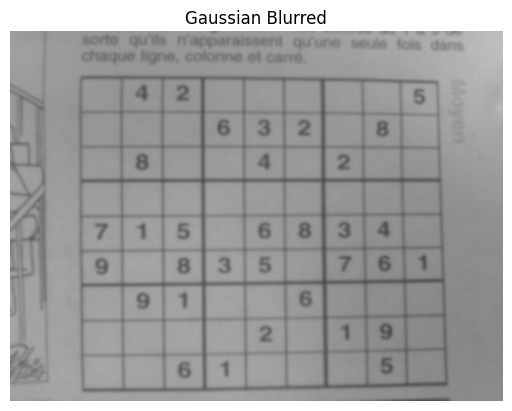

In [10]:
image = cv2.imread("images/image10.jpg", cv2.IMREAD_GRAYSCALE)
L = 5
box_kernel = np.ones((L, L)) / (L**2)
gaussian_kernel = create_gaussian_kernel(9, 1.6)

blurred_image = linear_filter(image, box_kernel)
median_filter_image = median_filter(image, L)
gaussian_image = linear_filter(image, gaussian_kernel)

display_image_grayscale(gaussian_image, "Gaussian Blurred")

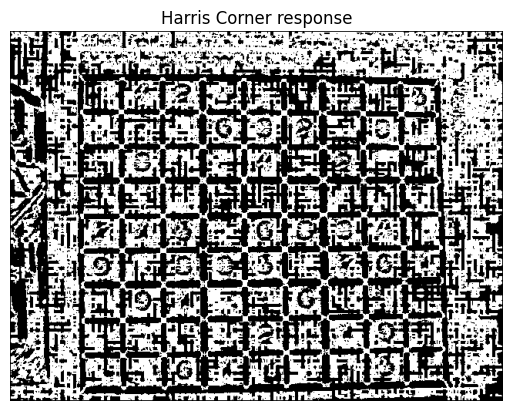

In [11]:
# Compute Harris corner response
response = harris_corners(image)

display_image_grayscale(response, "Harris Corner response")

Text(0.5, 1.0, 'Detected Corners')

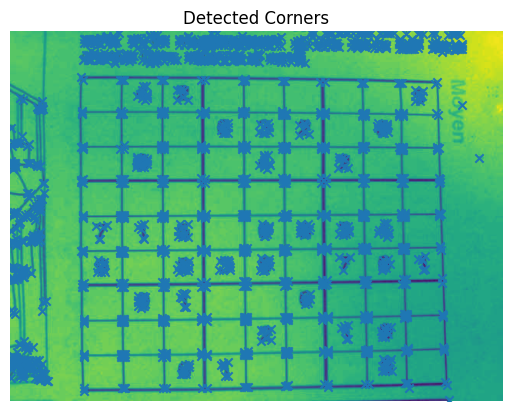

In [12]:
corners = corner_peaks(response, threshold_rel=0.01)

# Display detected corners
plt.imshow(image)
plt.scatter(corners[:,1], corners[:,0], marker='x')
plt.axis('off')
plt.title('Detected Corners')

In [13]:
sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

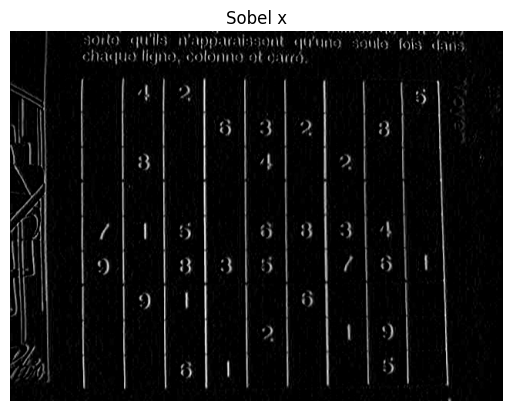

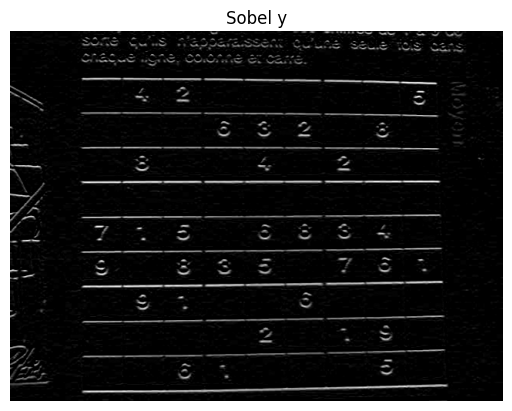

In [14]:
image_sobel_x = linear_filter(image, sobel_x_kernel)
image_sobel_y = linear_filter(image, sobel_y_kernel)
display_image_grayscale(image_sobel_x, "Sobel x")
display_image_grayscale(image_sobel_y, "Sobel y")

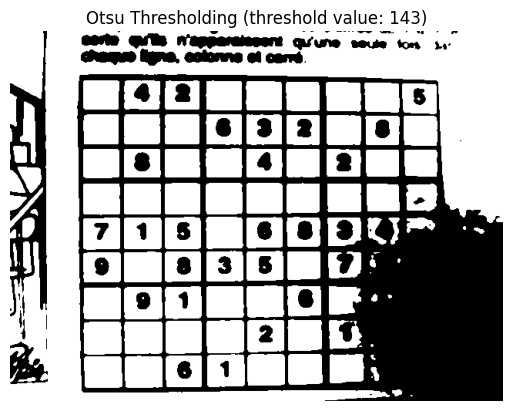

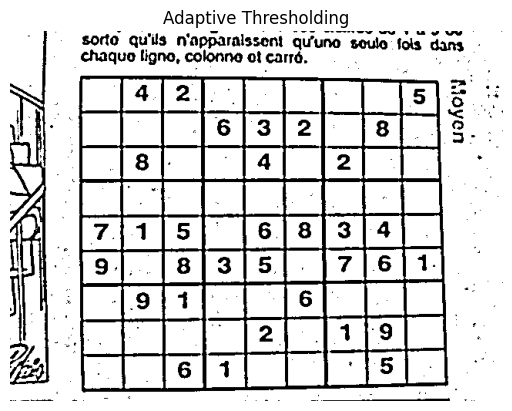

In [15]:
(hist, bin) = create_normalized_histogram(gaussian_image, 256)
threshold_val = find_otsu_threshold(hist)
image_thresh = perform_threshold(gaussian_image, threshold_val)
display_image_grayscale(image_thresh, f"Otsu Thresholding (threshold value: {threshold_val})")
display_image_grayscale(apply_adaptive_threshold(gaussian_image, 11, 1), "Adaptive Thresholding")

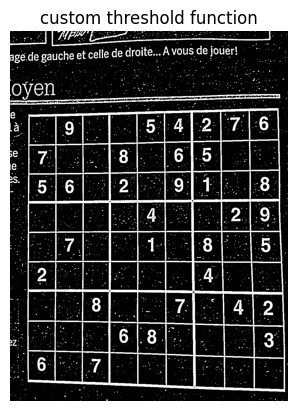

[[[ 925  266]]

 [[  63  289]]

 [[  61 1214]]

 [[ 949 1248]]]
[[ 925  266]
 [  63  289]
 [  61 1214]
 [ 949 1248]]


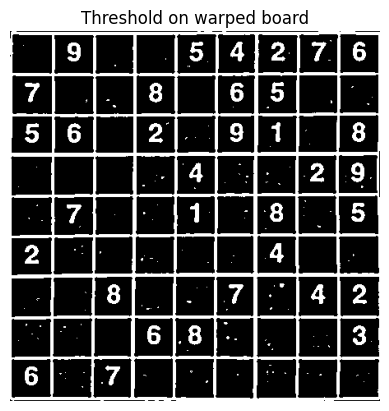

Successfully extracted 81 cells!


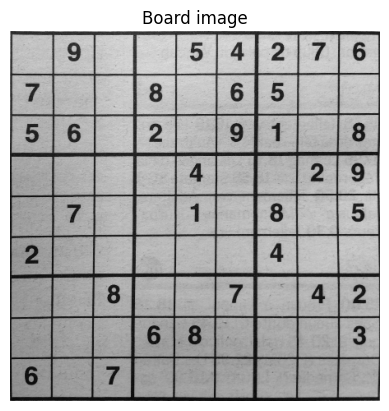

Are the cells empty?

True	False	True	True	False	False	False	False	False	
False	True	True	False	True	False	False	True	True	
False	False	True	False	True	False	False	True	False	
True	True	True	True	False	True	True	False	False	
True	False	True	True	False	True	False	True	False	
False	True	True	True	True	True	False	True	True	
True	True	False	True	True	False	True	False	False	
True	True	True	False	False	True	True	True	False	
False	True	False	True	True	True	True	True	True	

In [71]:
def order_points(pts):
    """
    Orders 4 points in the following format:
    [top-left, top-right, bottom-right, bottom-left]
    """
    rect = np.zeros((4, 2), dtype="float32")
    
    # The top-left point will have the smallest sum, whereas
    # the bottom-right point will have the largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # Now, compute the difference between the points, the
    # top-right point will have the smallest difference,
    # whereas the bottom-left will have the largest difference
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    return rect

@njit
def find_arc_length(coordinates, closed=False):
    '''
    coordinates should be a 2d array
    '''
    distance = 0
    (prev_x, prev_y) = coordinates[0,0], coordinates[0,1]
    for i in range(1, len(coordinates)):
        x = coordinates[i,0]
        y = coordinates[i,1]
        distance += math.sqrt((prev_x-x)**2 + (prev_y-y)**2)
        prev_x = x
        prev_y = y
    if closed:
        (x,y) = coordinates[0,0], coordinates[0,1]
        distance += math.sqrt((prev_x-x)**2 + (prev_y-y)**2)
    return distance

@njit
def find_area(coordinates):
    '''Calculates the area of a polygon using the Shoelace Formula'''
    n = len(coordinates)
    area = 0.0
    for i in range(n):
        j = (i+1) % n
        area += (coordinates[i, 0] * coordinates[j,1])
        area -= (coordinates[j, 0] * coordinates[i, 1])
    return area / 2
    
def is_cell_empty(cell_image, threshold_percent=0.07):
    '''
    Takes an INVERSE BINARY cell image (Ink=255, Paper=0).
    If less than 3% of the pixels are white, we assume it's empty.
    '''
    h, w = cell_image.shape
    margin = int(h * 0.15)
    center_crop = cell_image[margin:-margin, margin:-margin] # cropping the margin off the sides to not count sudoku grid lines
    
    # Count the number of white pixels (ink)
    total_pixels = center_crop.size
    white_pixels = np.count_nonzero(center_crop == 255)
    
    # Calculate the percentage of the crop that is ink
    ink_ratio = white_pixels / total_pixels
    
    # If the ink ratio is smaller than our threshold, it's empty
    return ink_ratio < threshold_percent

def approximate_polygon(coordinates, epsilon, closed):
    def recursive_helper(coordinates, epsilon, closed):
        maxDistance = 0
        index = 0
        end = len(coordinates)
        
        # coordinates of first and last point
        x1, x2 = coordinates[0][0], coordinates[end-1][0]
        y1, y2 = coordinates[0][1], coordinates[end-1][1]
    
        # Using the equation Ax + By + C = 0
        A = y1 - y2
        B = x2 - x1
        C = -(A*x1 + B*y1)
    
        # Find the point with the maximum distance
        for i in range(1, end-1):
            x_p, y_p = coordinates[i][0], coordinates[i][1]
            if closed == False:
                distance = abs(A*x_p + B*y_p + C) / math.sqrt(A**2 + B**2)
                denom = math.sqrt(A**2 + B**2)
                if denom == 0:
                    distance = 0
                else:
                    distance = abs(A*x_p + B*y_p + C) / denom
            else:
                distance = math.sqrt((x1 - x_p)**2 + (y1 - y_p)**2)
            if (distance > maxDistance):
                index = i
                maxDistance = distance
    
        result = np.array([])
        # If max distance is greater than epsilon, recursively simplify
        if (maxDistance > epsilon):
            # Recursive call
            result1 = approximate_polygon(coordinates[:index+1], epsilon, False)
            result2 = approximate_polygon(coordinates[index:], epsilon, False)
            result = np.concatenate([result1[:len(result1)-1], result2])
        else:
            # Discard all intermediate points
            result = np.array([[coordinates[0][0], coordinates[0][1]], [coordinates[end-1][0], coordinates[end-1][1]]])
        return result
    
    if epsilon <= 0:
        print("Epsilon must be greater than 0")
        return None
    if closed == True:
        coordinates = np.append(coordinates, [coordinates[0]], axis=0)
        result = recursive_helper(coordinates, epsilon, True)
        return result[:-1]
    return recursive_helper(coordinates, epsilon, False)
    

    
def extract_sudoku_cells(image_path):
    # Read the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found. Check the path.")
    
    original = img.copy()

    # Pre-process: Blur and Adaptive Thresholding
    # Gaussian blur reduces high-frequency noise
    gaussian_kernel = create_gaussian_kernel(9, 1.6)
    blurred = linear_filter(img, gaussian_kernel, clip=True)

    # Thresholding
    thresh = apply_adaptive_threshold(blurred, 11, 2, True)
    display_image_grayscale(thresh, "custom threshold function")

    # Find contours (I don't think we can build custom version)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

    # Assume the Sudoku board is the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea) # replace this with find_area function

    perimeter = find_arc_length(largest_contour[:,0,:], True)
    epsilon = 0.02 * perimeter

    largest_contour = largest_contour[:,0,:]
    approx = approximate_polygon(largest_contour, epsilon, True)
    # approx = cv2.approxPolyDP(largest_contour, epsilon, True) # Create our own function using Ramer-Douglas-Peucker algorithm
    if len(approx) != 4:
        raise ValueError("Could not find 4 corners of the Sudoku board. Try better lighting.")

    # Perspective Transform (Flatten the board)
    pts = approx.reshape(4, 2) # Will not need this with my custom approximate_polygon
    rect = order_points(pts)
    
    # Create a perfect square image to map the board to (450x450 is easily divisible by 9)
    side_length = 450
    dst = np.array([
        [0, 0],
        [side_length - 1, 0],
        [side_length - 1, side_length - 1],
        [0, side_length - 1]
    ], dtype="float32")

    # Calculate the homography matrix and apply it
    matrix = cv2.getPerspectiveTransform(rect, dst)
    warped_board = cv2.warpPerspective(original, matrix, (side_length, side_length))

    # Blur and apply threshold again but on the warped board this time. Used for determining if cell is empty.
    blurred_warped_board = linear_filter(warped_board, gaussian_kernel, clip=True)
    thresh_warped_board = apply_adaptive_threshold(blurred_warped_board, 11, 2, True)
    display_image_grayscale(thresh_warped_board, "Threshold on warped board")

    # Divide the board into 81 cells
    cells = []
    cell_size = side_length // 9
    
    for i in range(9): # Rows
        for j in range(9): # Columns
            y_start = i * cell_size
            y_end = (i + 1) * cell_size
            x_start = j * cell_size
            x_end = (j + 1) * cell_size
            
            # Extract the cell
            cell = warped_board[y_start:y_end, x_start:x_end]
            
            # Optional but recommended: Crop the inner margins slightly 
            # to remove the thick grid lines before feeding to a classifier
            margin = int(cell_size * 0.1) # 10% crop on all sides
            cell_cropped = cell[margin:-margin, margin:-margin]
            isEmpty = is_cell_empty(thresh_warped_board[y_start:y_end, x_start:x_end], threshold_percent=0.07)
            
            cells.append((cell_cropped, isEmpty))

    return warped_board, cells

# --- Execution ---
if __name__ == "__main__":
    # Replace with image path
    image_path = "data/sudoku_dataset/images/image1001.jpg" 
    
    try:
        board_img, sudoku_cells = extract_sudoku_cells(image_path)
        print(f"Successfully extracted {len(sudoku_cells)} cells!")
        
        # Test display two of the 81 cells
        display_image_grayscale(board_img, "Board image")
        print("Are the cells empty?")
        for i in range(81):
            if i % 9 == 0:
                print("")
            print(f"{sudoku_cells[i][1]}", end="\t")
        
    except Exception as e:
        print(f"Error: {e}")